In [2]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

def generar_senal(tipo, frecuencia, amplitud, fs, duracion):
    # 1. Validación (igual que en tu MATLAB)
    if frecuencia <= 0 or amplitud <= 0 or fs <= 0 or duracion <= 0:
        raise ValueError("Todos los parámetros deben ser mayores que 0")
    if frecuencia > fs / 2:
        raise ValueError("La frecuencia supera Fs/2: habría aliasing")

    # 2. Vector de tiempo y frecuencia angular
    n = int(round(duracion * fs))      # número de muestras
    t = np.arange(n) / fs              # 0, 1/fs, 2/fs, ...
    w = 2 * np.pi * frecuencia * t

    # 3. Selección de la forma de onda (el switch de MATLAB)
    if tipo == "seno":
        y = np.sin(w)
    elif tipo == "coseno":
        y = np.cos(w)
    elif tipo == "cuadrada":
        y = signal.square(w)
    elif tipo == "triangular":
        y = signal.sawtooth(w, 0.5)
    elif tipo == "sierra":
        y = signal.sawtooth(w)
    else:
        raise ValueError(f"Tipo desconocido: {tipo}")

    return t, amplitud * y

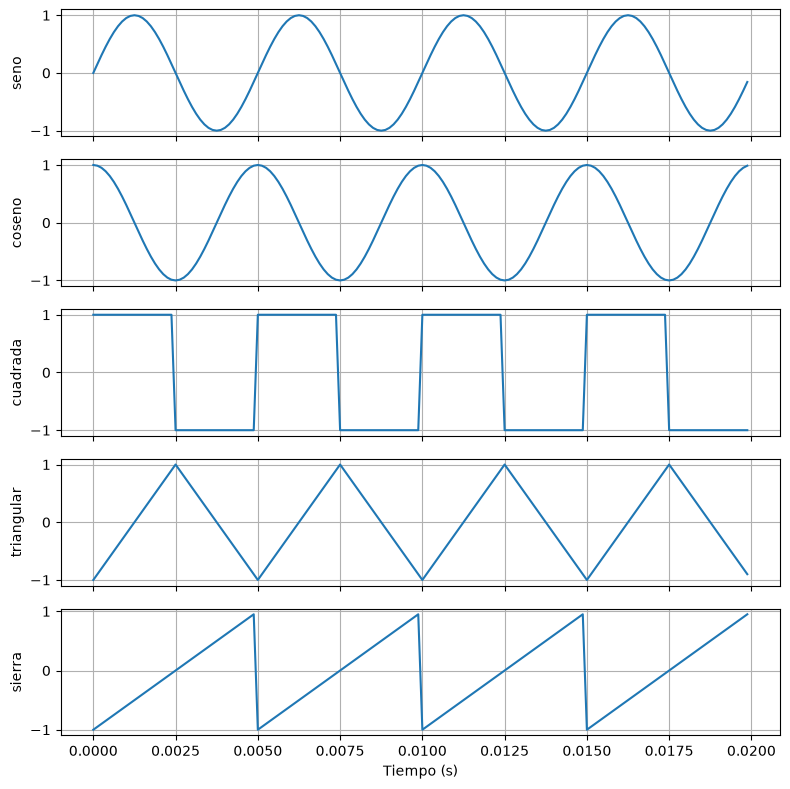

In [3]:
fs, f, amp, dur = 8000, 200, 1.0, 0.02   # 200 Hz durante 20 ms

fig, axs = plt.subplots(5, 1, figsize=(8, 8), sharex=True)

for ax, tipo in zip(axs, ["seno", "coseno", "cuadrada", "triangular", "sierra"]):
    t, y = generar_senal(tipo, f, amp, fs, dur)
    ax.plot(t, y)
    ax.set_ylabel(tipo)
    ax.grid(True)

axs[-1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

In [6]:
import soundfile as sf
from IPython.display import Audio

fs, f, amp, dur = 44100, 440, 0.5, 2.0    # La 440 Hz, 2 s, amplitud 0.5
t, y = generar_senal("seno", f, amp, fs, dur)

Audio(y, rate=fs)

In [7]:
sf.write("../data/seno_440.wav", y, fs)          # guardar

y2, fs2 = sf.read("../data/seno_440.wav")        # leer de vuelta
print("fs:", fs2, "| duración:", len(y2)/fs2, "s")
print("¿Coincide con la original?", np.allclose(y, y2, atol=1e-4))

fs: 44100 | duración: 2.0 s
¿Coincide con la original? True


In [9]:
%load_ext autoreload
%autoreload 2

from audiolab.generador import generar_senal

t, y = generar_senal("seno", 440, 0.5, 44100, 0.01)
print(len(y), generar_senal.__module__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
441 audiolab.generador


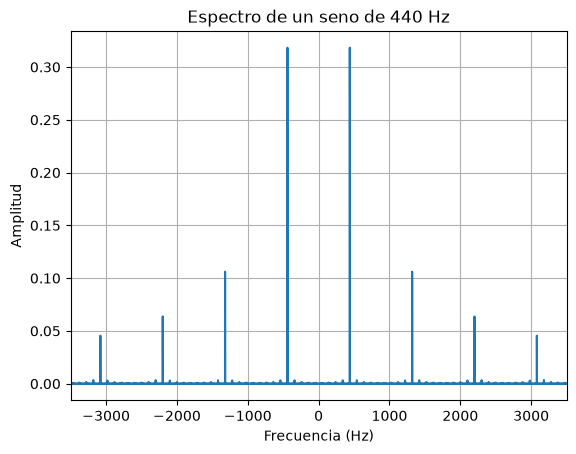

Pico en: 440.0 Hz | valor: 0.3183099131066679


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from audiolab.generador import generar_senal
from audiolab.analisis import calcular_espectro

fs = 44100
t, y = generar_senal("cuadrada", 440, 0.5, fs, 1.0)     # 1 segundo
f, P = calcular_espectro(y, fs)

plt.plot(f, P)
plt.xlim(-3500, 3500)                                # zoom alrededor de 0 Hz
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.title("Espectro de un seno de 440 Hz")
plt.grid(True)
plt.show()

pos = f > 0
print("Pico en:", f[pos][np.argmax(P[pos])], "Hz | valor:", P.max())

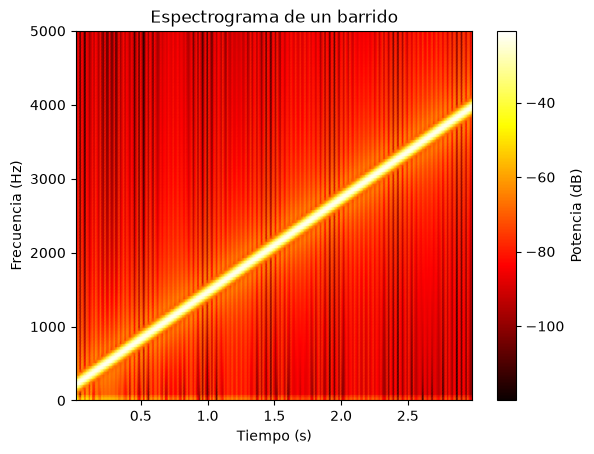

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from audiolab.analisis import calcular_espectrograma

fs = 44100
t = np.arange(0, 3.0, 1/fs)
y = signal.chirp(t, f0=200, t1=3.0, f1=4000)     # barrido de 200 a 4000 Hz en 3 s

f, tt, S_dB = calcular_espectrograma(y, fs)

plt.pcolormesh(tt, f, S_dB, cmap="hot", shading="gouraud")
plt.ylim(0, 5000)
plt.colorbar(label="Potencia (dB)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.title("Espectrograma de un barrido")
plt.show()

In [15]:
import numpy as np
from audiolab.generador import generar_senal
from audiolab.analisis import calcular_espectro
from audiolab.procesado import cambiar_velocidad, time_stretch

fs = 44100
t, y = generar_senal("seno", 440, 0.5, fs, 2.0)

def pico(y, fs):
    f, P = calcular_espectro(y, fs)
    pos = f > 0
    return f[pos][np.argmax(P[pos])]

y_a, fs_a = cambiar_velocidad(y, fs, 2)
y_b, fs_b = time_stretch(y, fs, 2)

print(f"Original:      {len(y)/fs:.2f} s | pico {pico(y, fs):.0f} Hz")
print(f"Velocidad x2:  {len(y_a)/fs_a:.2f} s | pico {pico(y_a, fs_a):.0f} Hz")
print(f"Time-stretch:  {len(y_b)/fs_b:.2f} s | pico {pico(y_b, fs_b):.0f} Hz")

c:\proyectos\audiolab\.venv\Lib\site-packages\librosa\effects.py:448: FutureWarning: The `hop_length` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(
c:\proyectos\audiolab\.venv\Lib\site-packages\librosa\effects.py:448: FutureWarning: The `n_fft` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(


Original:      2.00 s | pico 440 Hz
Velocidad x2:  1.00 s | pico 880 Hz
Time-stretch:  1.00 s | pico 440 Hz


In [16]:
from IPython.display import Audio, display

display(Audio(y_a, rate=fs_a))   # cambio de velocidad: más agudo
display(Audio(y_b, rate=fs_b))   # time-stretch: mismo tono

fs: 44100 Hz | muestras: 1649664 | duración: 37.41 s | rango: [-0.38, 0.39]


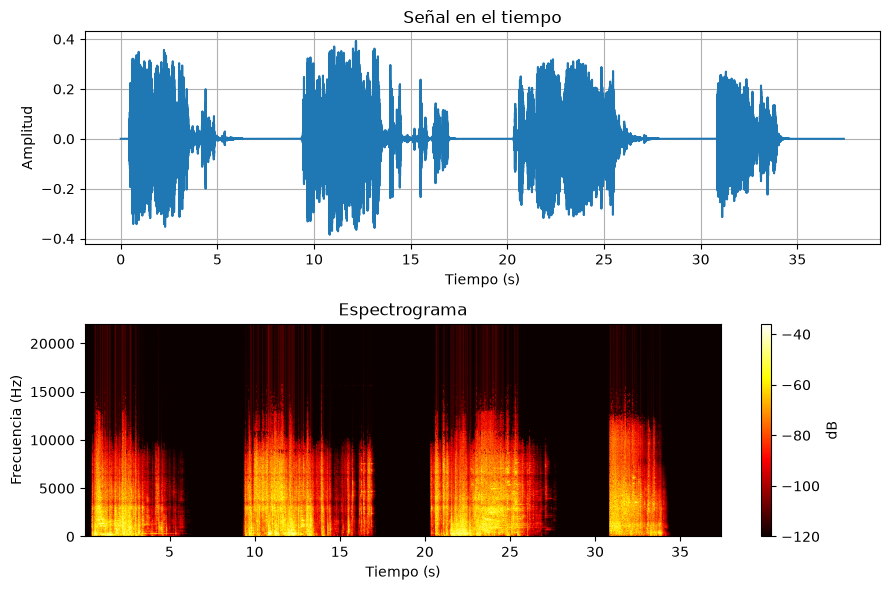

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
from audiolab.audio_io import cargar_audio
from audiolab.analisis import calcular_espectrograma

y, fs = cargar_audio("../data/metal.mp3")     # ← pon aquí el nombre de tu archivo
print(f"fs: {fs} Hz | muestras: {len(y)} | duración: {len(y)/fs:.2f} s | rango: [{y.min():.2f}, {y.max():.2f}]")

t = np.arange(len(y)) / fs
f, tt, S_dB = calcular_espectrograma(y, fs)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))
ax1.plot(t, y)
ax1.set_title("Señal en el tiempo")
ax1.set_xlabel("Tiempo (s)")
ax1.set_ylabel("Amplitud")
ax1.grid(True)

im = ax2.pcolormesh(tt, f, S_dB, cmap="hot", shading="gouraud")
ax2.set_title("Espectrograma")
ax2.set_xlabel("Tiempo (s)")
ax2.set_ylabel("Frecuencia (Hz)")
fig.colorbar(im, ax=ax2, label="dB")

plt.tight_layout()
plt.show()

Audio(y, rate=fs)

🎙️ Grabando 3 segundos... habla ahora
✅ Grabación terminada
fs: 44100 Hz | muestras: 132300 | amplitud máxima: 0.872


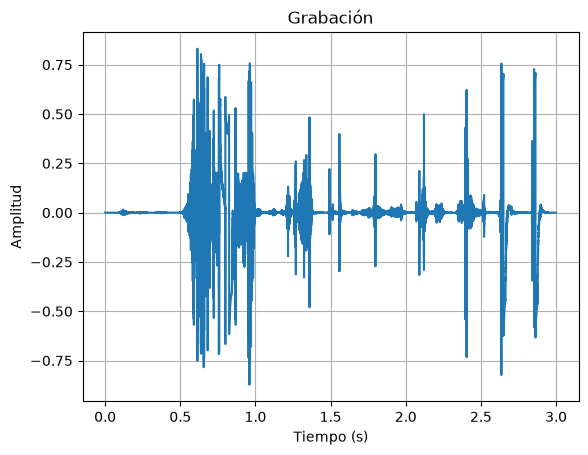

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
from audiolab.audio_io import grabar_audio, guardar_audio

print("🎙️ Grabando 3 segundos... habla ahora")
y, fs = grabar_audio(3)
print("✅ Grabación terminada")

print(f"fs: {fs} Hz | muestras: {len(y)} | amplitud máxima: {np.abs(y).max():.3f}")

t = np.arange(len(y)) / fs
plt.plot(t, y)
plt.title("Grabación")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

guardar_audio("../data/grabacion.wav", y, fs)
Audio(y, rate=fs)

X: (800, 16000) | y: (800,)
seno -> 200 señales
cuadrada -> 200 señales
triangular -> 200 señales
sierra -> 200 señales


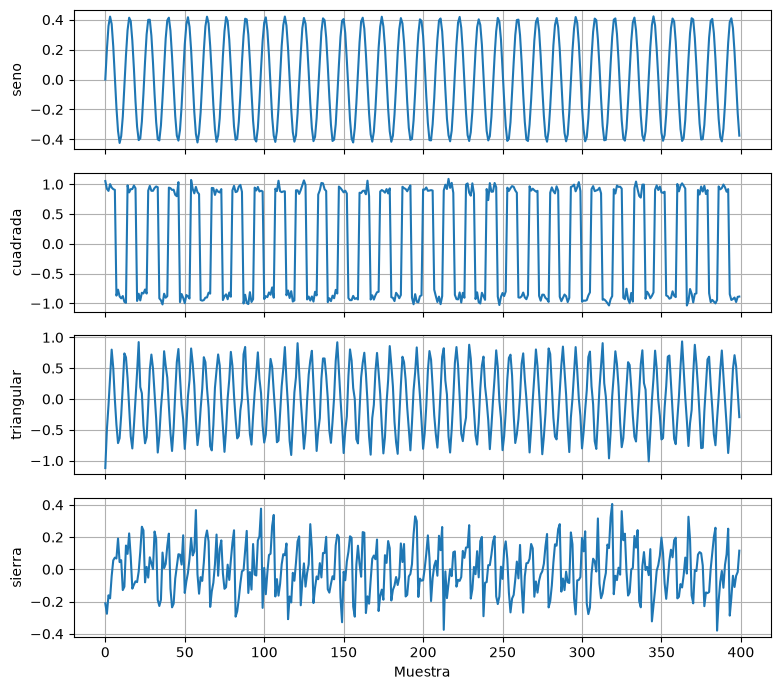

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from audiolab.dataset import generar_dataset, TIPOS

X, y = generar_dataset(n_por_clase=200)

print("X:", X.shape, "| y:", y.shape)
for tipo in TIPOS:
    print(tipo, "->", np.sum(y == tipo), "señales")

fig, axs = plt.subplots(4, 1, figsize=(8, 7), sharex=True)
for ax, tipo in zip(axs, TIPOS):
    ejemplo = X[y == tipo][0]
    ax.plot(ejemplo[:400])
    ax.set_ylabel(tipo)
    ax.grid(True)
axs[-1].set_xlabel("Muestra")
plt.tight_layout()
plt.show()

In [20]:
import numpy as np
from audiolab.dataset import generar_dataset
from audiolab.features import extraer_features_dataset

fs = 16000
X, y = generar_dataset(n_por_clase=200, fs=fs)

X_feat = extraer_features_dataset(X, fs)

print("Señales:  ", X.shape)
print("Features: ", X_feat.shape)
print("Primeras 5 features de la primera señal:", np.round(X_feat[0][:5], 1))

Señales:   (800, 16000)
Features:  (800, 40)
Primeras 5 features de la primera señal: [-289.6    9.5  -25.2  -18.    13.7]


Entrenamiento: (640, 40) | Prueba: (160, 40)
Accuracy entrenamiento: 1.0
Accuracy prueba:        0.85


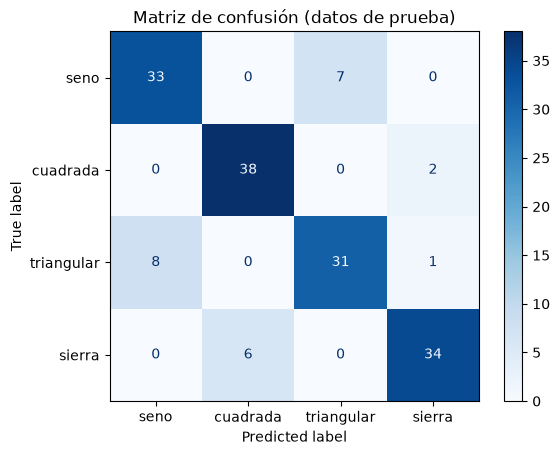

In [21]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from audiolab.dataset import TIPOS

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.2, stratify=y, random_state=0
)
print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)

modelo = RandomForestClassifier(n_estimators=200, random_state=0)
modelo.fit(X_train, y_train)

print("Accuracy entrenamiento:", modelo.score(X_train, y_train))
print("Accuracy prueba:       ", modelo.score(X_test, y_test))

y_pred = modelo.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=TIPOS, cmap="Blues")
plt.title("Matriz de confusión (datos de prueba)")
plt.show()

In [22]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from audiolab.features import extraer_features_armonicos_dataset
from audiolab.dataset import TIPOS

X_arm = extraer_features_armonicos_dataset(X, fs)
print("Features de armónicos:", X_arm.shape)

def evaluar(D, nombre):
    D_train, D_test, y_train, y_test = train_test_split(
        D, y, test_size=0.2, stratify=y, random_state=0
    )
    modelo = RandomForestClassifier(n_estimators=200, random_state=0).fit(D_train, y_train)
    print(f"{nombre:12s} entrenamiento: {modelo.score(D_train, y_train):.3f} | prueba: {modelo.score(D_test, y_test):.3f}")

evaluar(X_feat, "MFCC")
evaluar(X_arm, "Armónicos")
evaluar(np.hstack([X_feat, X_arm]), "Ambas")

Features de armónicos: (800, 8)
MFCC         entrenamiento: 1.000 | prueba: 0.850
Armónicos    entrenamiento: 1.000 | prueba: 1.000
Ambas        entrenamiento: 1.000 | prueba: 1.000


In [23]:
np.set_printoptions(precision=2, suppress=True)
for tipo in TIPOS:
    print(f"{tipo:11s}", X_arm[y == tipo][:, 1:].mean(axis=0))

seno        [0. 0. 0. 0. 0. 0. 0.]
cuadrada    [0.   0.33 0.   0.14 0.   0.06 0.  ]
triangular  [0.   0.11 0.   0.03 0.   0.01 0.  ]
sierra      [0.5  0.34 0.25 0.16 0.11 0.07 0.05]
